Saved -> chizat_torus_validation.gif


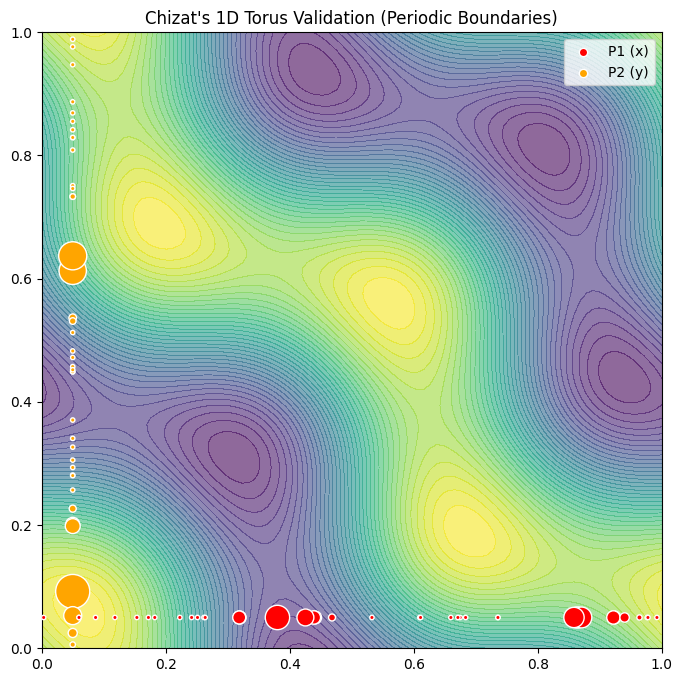

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# =====================================================================
# 1. Random Fourier Game (Matches the paper's bounded objective)
# =====================================================================
class RandomFourierTorusGame:
    def __init__(self, K=5, seed=42):
        """
        Creates a random min-max game on the Torus [0, 1) x [0, 1)
        using Fourier features: sum c_k * cos(2*pi*(u_k*x + v_k*y) + phi_k)
        """
        rng = np.random.default_rng(seed)
        self.K = K
        self.c = rng.normal(0, 1, self.K)
        # Integer frequencies so the function is perfectly periodic on [0,1]
        self.u = rng.integers(-2, 3, self.K)
        self.v = rng.integers(-2, 3, self.K)
        self.phi = rng.uniform(0, 2*np.pi, self.K)

    def f(self, x, y):
        val = 0.0
        # for k in range(self.K):
            # val += self.c[k] * np.cos(2*np.pi*(self.u[k]*x + self.v[k]*y) + self.phi[k])
        val = np.sin(4*np.pi*x) + np.sin(4*np.pi*y)  + 2*np.cos(2*np.pi*(x + y))
        return val

    def grad_f(self, x, y):
        gx, gy = 0.0, 0.0
        # for k in range(self.K):
        #     sin_term = np.sin(2*np.pi*(self.u[k]*x + self.v[k]*y) + self.phi[k])
        #     gx -= self.c[k] * 2 * np.pi * self.u[k] * sin_term
        #     gy -= self.c[k] * 2 * np.pi * self.v[k] * sin_term
        g_x = 4*np.pi*np.cos(4*np.pi*x) - 4*np.pi*np.sin(2*np.pi*(x + y))
        g_y = 4*np.pi*np.cos(4*np.pi*y) - 4*np.pi**np.sin(2*np.pi*(x + y))
        return gx, gy

# =====================================================================
# 2. Conic Particle Mirror Prox (Faithful to CPMP_1D.jl)
# =====================================================================
def run_chizat_torus(game, T=100, mx=30, my=30, eta=0.01, extrasteps=2):
    rng = np.random.default_rng(1234)

    # Initialize weights uniformly
    wx = np.ones(mx) / mx
    wy = np.ones(my) / my

    # Initialize positions uniformly on [0, 1)
    x = rng.uniform(0, 1, mx)
    y = rng.uniform(0, 1, my)

    history = {'wx': [], 'x': [], 'wy': [], 'y': []}

    for t in range(T):
        history['wx'].append(wx.copy())
        history['x'].append(x.copy())
        history['wy'].append(wy.copy())
        history['y'].append(y.copy())

        # "Ghost" step initialization
        wxp, xp, wyp, yp = wx.copy(), x.copy(), wy.copy(), y.copy()

        # The Inner Loop (extrasteps=1 is CPMDA, extrasteps=2 is CPMP)
        for _ in range(extrasteps):
            Dwx, Dwy = np.zeros(mx), np.zeros(my)
            Dx, Dy   = np.zeros(mx), np.zeros(my)

            # Evaluate gradients at the predicted points (wxp, xp, wyp, yp)
            for i in range(mx):
                for j in range(my):
                    val = game.f(xp[i], yp[j])
                    gx, gy = game.grad_f(xp[i], yp[j])

                    Dwx[i] += wyp[j] * val
                    Dwy[j] += wxp[i] * val
                    Dx[i]  += wxp[i] * wyp[j] * gx
                    Dy[j]  += wxp[i] * wyp[j] * gy

            # ----- RAW PAPER UPDATES (NO STABILIZATIONS) -----
            # Weight update
            wx1 = wx * np.exp(-eta * Dwx)
            wx1 /= np.sum(wx1)
            wy1 = wy * np.exp(eta * Dwy)
            wy1 /= np.sum(wy1)

            # Position update (Dividing directly by wxp, matching their `true_prox=false` logic)
            # Failsafe 1e-15 is just to prevent zero-division Python crashes, but allows huge jumps
            x1 = x - eta * Dx / np.maximum(wxp, 1e-15)
            y1 = y + eta * Dy / np.maximum(wyp, 1e-15)

            wxp, xp, wyp, yp = wx1, x1, wy1, y1

        # Take the final evaluated step
        wx, x, wy, y = wxp, xp, wyp, yp



        # Floor to [0,1). This traps the massive ghost particle jumps!
        x = x % 1.0
        y = y % 1.0

    return history

# =====================================================================
# 3. Visualization (Torus Landscape & Particles)
# =====================================================================
def animate_torus_experiment():
    game = RandomFourierTorusGame(K=6, seed=42)
    history = run_chizat_torus(game, T=1500, mx=40, my=40, eta=0.03, extrasteps=2)

    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot the Torus Landscape [0,1] x [0,1]
    grid = np.linspace(0, 1, 100)
    X, Y = np.meshgrid(grid, grid)
    Z = np.zeros_like(X)
    for i in range(100):
        for j in range(100):
            Z[i, j] = game.f(X[i, j], Y[i, j])

    contour = ax.contourf(X, Y, Z, levels=40, cmap='viridis', alpha=0.6)

    # Particles
    scat_p1 = ax.scatter([], [], c='red', edgecolors='white', zorder=5, label='P1 (x)')
    scat_p2 = ax.scatter([], [], c='orange', edgecolors='white', zorder=4, label='P2 (y)')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title("Chizat's 1D Torus Validation (Periodic Boundaries)")
    ax.legend()

    def update(frame):
        wx, x = history['wx'][frame], history['x'][frame]
        wy, y = history['wy'][frame], history['y'][frame]

        # In a 1D vs 1D game, we visualize P1 on the X axis, P2 on the Y axis
        # Plotting them slightly off the edges so they are visible
        scat_p1.set_offsets(np.c_[x, np.full_like(x, 0.05)])
        scat_p1.set_sizes(np.maximum(wx * 2000, 10))  # Scale by probability mass

        scat_p2.set_offsets(np.c_[np.full_like(y, 0.05), y])
        scat_p2.set_sizes(np.maximum(wy * 2000, 10))

    ani = animation.FuncAnimation(fig, update, frames=len(history['x']), interval=100)
    ani.save("chizat_torus_validation.gif", writer='pillow')
    print("Saved -> chizat_torus_validation.gif")

if __name__ == "__main__":
    animate_torus_experiment()

Running CP-MDA (extrasteps=1)...
Running CP-MP (extrasteps=2)...


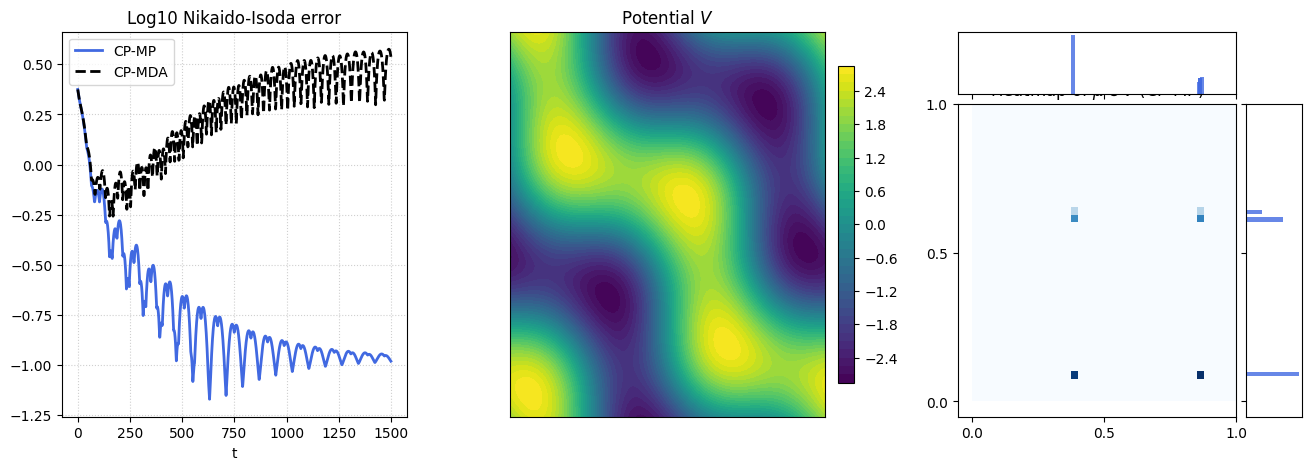

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# # =====================================================================
# # 1. Random Fourier Game (Torus [0, 1) x [0, 1))
# # =====================================================================
# class RandomFourierTorusGame:
#     def __init__(self, K=5, seed=42):
#         rng = np.random.default_rng(seed)
#         self.K = K
#         self.c = np.sqrt(np.random.gamma(1., 1., self.K))  # rng.normal(0, 1, self.K)
#         self.u = rng.integers(-2, 3, self.K)
#         self.v = rng.integers(-2, 3, self.K)
#         self.phi = rng.uniform(0, 2*np.pi, self.K)

#     def f(self, x, y):
#         # Vectorized evaluation
#         x = np.asarray(x)
#         y = np.asarray(y)
#         val = np.zeros(np.broadcast(x, y).shape)
#         for k in range(self.K):
#             val += self.c[k] * np.cos(2*np.pi*(self.u[k]*x + self.v[k]*y) + self.phi[k])
#         return val

#     def grad_f(self, x, y):
#         gx, gy = 0.0, 0.0
#         for k in range(self.K):
#             sin_term = np.sin(2*np.pi*(self.u[k]*x + self.v[k]*y) + self.phi[k])
#             gx -= self.c[k] * 2 * np.pi * self.u[k] * sin_term
#             gy -= self.c[k] * 2 * np.pi * self.v[k] * sin_term
#         return gx, gy

# =====================================================================
# 1. Random Fourier Game (Matches the paper's bounded objective)
# =====================================================================
class RandomFourierTorusGame:
    def __init__(self, K=5, seed=42):
        """
        Creates a random min-max game on the Torus [0, 1) x [0, 1)
        using Fourier features: sum c_k * cos(2*pi*(u_k*x + v_k*y) + phi_k)
        """
        rng = np.random.default_rng(seed)
        self.K = K
        self.c = rng.normal(0, 1, self.K)
        # Integer frequencies so the function is perfectly periodic on [0,1]
        self.u = rng.integers(-2, 3, self.K)
        self.v = rng.integers(-2, 3, self.K)
        self.phi = rng.uniform(0, 2*np.pi, self.K)

    def f(self, x, y):
        val = 0.0
        # for k in range(self.K):
            # val += self.c[k] * np.cos(2*np.pi*(self.u[k]*x + self.v[k]*y) + self.phi[k])
        val = np.sin(4*np.pi*x) + np.sin(4*np.pi*y)  + 2*np.cos(2*np.pi*(x + y))
        return val

    def grad_f(self, x, y):
        gx, gy = 0.0, 0.0
        # for k in range(self.K):
        #     sin_term = np.sin(2*np.pi*(self.u[k]*x + self.v[k]*y) + self.phi[k])
        #     gx -= self.c[k] * 2 * np.pi * self.u[k] * sin_term
        #     gy -= self.c[k] * 2 * np.pi * self.v[k] * sin_term
        g_x = 4*np.pi*np.cos(4*np.pi*x) - 4*np.pi*np.sin(2*np.pi*(x + y))
        g_y = 4*np.pi*np.cos(4*np.pi*y) - 4*np.pi**np.sin(2*np.pi*(x + y))
        return gx, gy

# =====================================================================
# 2. Nikaido-Isoda (NI) Error Calculator
# =====================================================================
def compute_ni_error(game, wx, x, wy, y, grid_size=200):
    """
    Computes the duality gap: max_y' F(mu, y') - min_x' F(x', nu)
    """
    grid = np.linspace(0, 1, grid_size)

    # 1. max_y' sum_i wx_i * f(x_i, y')
    # x is shape (N, 1), grid is shape (1, 200) -> F_mat is (N, 200)
    F_mat_y = game.f(x[:, None], grid[None, :])
    val_y = wx @ F_mat_y  # Dot product gives shape (200,)
    max_y = np.max(val_y)

    # 2. min_x' sum_j wy_j * f(x', y_j)
    F_mat_x = game.f(grid[:, None], y[None, :])
    val_x = F_mat_x @ wy
    min_x = np.min(val_x)

    return max_y - min_x

# =====================================================================
# 3. Conic Particle Simulator
# =====================================================================
def run_chizat_torus(game, T=100, mx=40, my=40, eta=0.03, extrasteps=2):
    rng = np.random.default_rng(1234)
    wx, wy = np.ones(mx) / mx, np.ones(my) / my
    x, y = rng.uniform(0, 1, mx), rng.uniform(0, 1, my)

    history = {'wx': [], 'x': [], 'wy': [], 'y': [], 'ni_error': []}

    for t in range(T):
        # Record state and NI error every step
        history['wx'].append(wx.copy()); history['x'].append(x.copy())
        history['wy'].append(wy.copy()); history['y'].append(y.copy())
        history['ni_error'].append(compute_ni_error(game, wx, x, wy, y))

        wxp, xp, wyp, yp = wx.copy(), x.copy(), wy.copy(), y.copy()

        for _ in range(extrasteps):
            Dwx, Dwy, Dx, Dy = np.zeros(mx), np.zeros(my), np.zeros(mx), np.zeros(my)
            for i in range(mx):
                for j in range(my):
                    val = game.f(xp[i], yp[j])
                    gx, gy = game.grad_f(xp[i], yp[j])
                    Dwx[i] += wyp[j] * val; Dwy[j] += wxp[i] * val
                    Dx[i]  += wxp[i] * wyp[j] * gx; Dy[j]  += wxp[i] * wyp[j] * gy

            wx1 = wx * np.exp(-eta * Dwx)
            wy1 = wy * np.exp(eta * Dwy)
            wx1 /= np.sum(wx1); wy1 /= np.sum(wy1)

            x1 = x - eta * Dx / np.maximum(wxp, 1e-15)
            y1 = y + eta * Dy / np.maximum(wyp, 1e-15)
            wxp, xp, wyp, yp = wx1, x1, wy1, y1

        wx, x, wy, y = wxp, xp, wyp, yp
        x = x % 1.0  # Periodic Torus Floor
        y = y % 1.0

    return history

# =====================================================================
# 4. Generate the Multi-Panel Replicated Figure
# =====================================================================
def generate_paper_figure():
    game = RandomFourierTorusGame(K=6, seed=42)

    print("Running CP-MDA (extrasteps=1)...")
    hist_cpmda = run_chizat_torus(game, T=1500, mx=40, my=40, eta=0.04, extrasteps=1)

    print("Running CP-MP (extrasteps=2)...")
    hist_cpmp = run_chizat_torus(game, T=1500, mx=40, my=40, eta=0.04, extrasteps=2)

    # ---- Setup Figure Layout ----
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5), gridspec_kw={'wspace': 0.3})

    # ---- Panel 1: Log10 NI Error ----
    ni_cpmda = np.maximum(hist_cpmda['ni_error'], 1e-16) # Prevent log(0)
    ni_cpmp = np.maximum(hist_cpmp['ni_error'], 1e-16)

    ax1.plot(np.log10(ni_cpmp), color='royalblue', linewidth=2, label='CP-MP')
    ax1.plot(np.log10(ni_cpmda), color='black', linestyle='--', linewidth=2, label='CP-MDA')
    ax1.set_title("Log10 Nikaido-Isoda error")
    ax1.set_xlabel("t")
    ax1.legend()
    ax1.grid(True, linestyle=':', alpha=0.6)

    # ---- Panel 2: Potential V ----
    grid = np.linspace(0, 1, 100)
    X, Y = np.meshgrid(grid, grid)
    Z = game.f(X, Y)

    c = ax2.contourf(X, Y, Z, levels=50, cmap='viridis')
    fig.colorbar(c, ax=ax2, fraction=0.046, pad=0.04)
    ax2.set_title("Potential $V$")
    ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
    ax2.set_xticks([]); ax2.set_yticks([]) # Remove ticks to match paper

    # ---- Panel 3: Heatmap with Marginal Histograms ----
    # Extract final states of CP-MP
    x_final = hist_cpmp['x'][-1]
    y_final = hist_cpmp['y'][-1]
    wx_final = hist_cpmp['wx'][-1]
    wy_final = hist_cpmp['wy'][-1]

    # Create joint distribution weights: a_i * b_j
    X_parts, Y_parts = np.meshgrid(x_final, y_final, indexing='ij')
    W_parts = np.outer(wx_final, wy_final)

    # 2D Histogram for the heatmap
    heatmap, xedges, yedges = np.histogram2d(
        X_parts.ravel(), Y_parts.ravel(),
        bins=40, range=[[0, 1], [0, 1]], weights=W_parts.ravel()
    )

    # Plot heatmap
    im = ax3.imshow(heatmap.T, origin='lower', extent=[0, 1, 0, 1], cmap='Blues', aspect='auto')
    ax3.set_title(r"Heatmap of $\mu \otimes \nu$ (CP-MP)")
    ax3.set_xticks([0, 0.5, 1.0])
    ax3.set_yticks([0, 0.5, 1.0])

    # Add marginal histograms using make_axes_locatable
    divider = make_axes_locatable(ax3)
    ax_histx = divider.append_axes("top", size="20%", pad=0.1, sharex=ax3)
    ax_histy = divider.append_axes("right", size="20%", pad=0.1, sharey=ax3)

    # Remove labels from the marginal axes
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histx.set_yticks([])
    ax_histy.set_xticks([])

    # Plot marginal distributions as filled bar charts
    ax_histx.bar(x_final, wx_final, width=0.015, color='royalblue', alpha=0.8)
    ax_histy.barh(y_final, wy_final, height=0.015, color='royalblue', alpha=0.8)

    plt.savefig("paper_replication_figure.png", dpi=150, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    generate_paper_figure()